In [1]:
import io
import keras
import numpy as np
import pandas as pd
import plotly.express as px

from matplotlib import pyplot as plt
from matplotlib.lines import Line2D

# Configure pandas display settings
pd.options.display.max_rows = 10
pd.options.display.float_format = "{:.1f}".format

print("All imports successfully loaded.")

All imports successfully loaded.


In [2]:
# It directly reads the rice dataset in CSV format from the given internet address and loads it into a Pandas DataFrame.
rice_dataset_raw=pd.read_csv("https://download.mlcc.google.com/mledu-datasets/Rice_Cammeo_Osmancik.csv")

In [3]:
## Filters the raw dataset by selecting only the features to be used in the analysis and the target variable ('Class').
rice_dataset=rice_dataset_raw[[
    'Area',
    'Perimeter',
    'Major_Axis_Length',
    'Minor_Axis_Length',
    'Eccentricity',
    'Convex_Area',
    'Extent',
    'Class',
]]
# Summarizes the basic statistical data (number, mean, standard deviation, min, max, etc.) of the selected numerical columns in a table.
rice_dataset.describe()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
count,3810.0,3810.0,3810.0,3810.0,3810.0,3810.0,3810.0
mean,12667.7,454.2,188.8,86.3,0.9,12952.5,0.7
std,1732.4,35.6,17.4,5.7,0.0,1777.0,0.1
min,7551.0,359.1,145.3,59.5,0.8,7723.0,0.5
25%,11370.5,426.1,174.4,82.7,0.9,11626.2,0.6
50%,12421.5,448.9,185.8,86.4,0.9,12706.5,0.6
75%,13950.0,483.7,203.6,90.1,0.9,14284.0,0.7
max,18913.0,548.4,239.0,107.5,0.9,19099.0,0.9


In [4]:
# Prints the shortest and longest 'Major_Axis_Length' values ​​of the rice grains to the screen.
print(
    f'The shortest grain is {rice_dataset.Major_Axis_Length.min():.1f}px long,'
    f' while the longest is {rice_dataset.Major_Axis_Length.max():.1f}px.'
)
# Prints the smallest and largest 'Area' values ​​of the rice grains to the screen.
print(
    f'The smallest rice grain has an area of {rice_dataset.Area.min()}px, while'
    f' the largest has an area of {rice_dataset.Area.max()}px.'
)
# Calculates how many standard deviations away the largest environmental value is from the mean.
print(
    'The largest rice grain, with a perimeter of'
    f' {rice_dataset.Perimeter.max():.1f}px, is'
    f' ~{(rice_dataset.Perimeter.max() - rice_dataset.Perimeter.mean())/rice_dataset.Perimeter.std():.1f} standard'
    f' deviations ({rice_dataset.Perimeter.std():.1f}) from the mean'
    f' ({rice_dataset.Perimeter.mean():.1f}px).'
)

# Shows the mathematical formula and result of the standard deviation calculation performed in the previous step.
print(
    f'This is calculated as: ({rice_dataset.Perimeter.max():.1f} -'
    f' {rice_dataset.Perimeter.mean():.1f})/{rice_dataset.Perimeter.std():.1f} ='
    f' {(rice_dataset.Perimeter.max() - rice_dataset.Perimeter.mean())/rice_dataset.Perimeter.std():.1f}'
)

The shortest grain is 145.3px long, while the longest is 239.0px.
The smallest rice grain has an area of 7551px, while the largest has an area of 18913px.
The largest rice grain, with a perimeter of 548.4px, is ~2.6 standard deviations (35.6) from the mean (454.2px).
This is calculated as: (548.4 - 454.2)/35.6 = 2.6


In [5]:
# Iterates through the specified pairs of x and y-axis variables sequentially;
#it plots interactive scatter plots colored according to rice types ('Class') using Plotly Express (px).
for x_axis_data,y_axis_data in [
    ('Area', 'Eccentricity'),
    ('Convex_Area', 'Perimeter'),
    ('Major_Axis_Length', 'Minor_Axis_Length'),
    ('Perimeter', 'Extent'),
    ('Eccentricity', 'Major_Axis_Length'),
]:
 px.scatter(rice_dataset, x=x_axis_data, y=y_axis_data, color='Class').show()

In [6]:
x_axis_data = 'Perimeter'  # @param {type: "string"}
y_axis_data = 'Extent'  # @param {type: "string"}
z_axis_data = 'Eccentricity'  # @param {type: "string"}

px.scatter_3d(rice_dataset,
              x=x_axis_data,
              y=y_axis_data,
              z=z_axis_data,
              color='Class').show()

In [7]:
# Calculate the mean and standard deviation of numerical features, scaling the data to a mean of 0 and a standard deviation of 1 ($Z$-score).
feature_mean=rice_dataset.mean(numeric_only=True)
feature_std=rice_dataset.std(numeric_only=True)
numerical_features=rice_dataset.select_dtypes('number').columns
normalized_dataset=(rice_dataset[numerical_features]-feature_mean)/feature_std
#Copy the class to new dataframe
normalized_dataset['Class']=rice_dataset['Class']
# Displays the first 5 rows of the newly normalized dataset resulting from the operations.
normalized_dataset.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,1.5,2.0,2.3,-0.2,2.0,1.5,-1.2,Cammeo
1,1.1,1.1,1.0,0.9,0.4,1.2,-0.6,Cammeo
2,1.1,1.3,1.5,0.3,1.2,1.1,0.4,Cammeo
3,0.3,0.1,0.3,0.2,0.2,0.2,-0.3,Cammeo
4,1.2,1.5,1.3,0.5,1.0,1.3,-0.2,Cammeo


In [8]:
keras.utils.set_random_seed(42)

In [9]:
normalized_dataset['Class_Bool'] = (
    # Returns true if class is Cammeo, and false if class is Osmancik
    normalized_dataset['Class'] == 'Cammeo'
).astype(int)
normalized_dataset.sample(10)

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class,Class_Bool
1011,-0.1,0.1,-0.1,0.2,-0.1,-0.0,-1.0,Cammeo,1
3185,-0.1,-0.5,-0.5,0.4,-0.8,-0.2,-0.3,Osmancik,0
3698,0.1,-0.1,-0.4,0.9,-1.1,0.1,-0.2,Osmancik,0
897,0.2,0.5,0.8,-0.5,1.2,0.2,1.5,Cammeo,1
3245,-1.3,-1.3,-0.9,-1.6,0.5,-1.4,-1.1,Osmancik,0
478,0.2,0.2,0.4,-0.0,0.5,0.2,1.7,Cammeo,1
1731,-0.4,-0.8,-0.8,0.3,-1.0,-0.5,-0.4,Osmancik,0
1025,0.6,0.7,0.6,0.3,0.5,0.6,-0.5,Cammeo,1
429,1.2,1.2,1.4,0.6,1.0,1.2,1.8,Cammeo,1
1330,-0.4,-0.0,0.4,-1.3,1.4,-0.5,-0.1,Cammeo,1


In [12]:
# Defines boundary indices to divide the dataset into 80% training, 10% validation, and 10% testing.
number_samples=len(normalized_dataset)
index_80th=round(number_samples*0.8)
index_90th=index_80th+round(number_samples*0.1)

# To prevent the model from memorizing the row order, it randomly shuffles the entire dataset (`random_state` ensures stability).
shuffeld_dataset=normalized_dataset.sample(frac=1,random_state=100)
# Divides the scrambled data into three independent clusters at specified ratios (80%/10%/10%) using `iloc`.
train_data=shuffeld_dataset.iloc[0:index_80th]
validation_data=shuffeld_dataset.iloc[index_80th:index_90th]
test_data=shuffeld_dataset.iloc[index_90th:]
# Displays the first 5 rows of the separated test dataset.
test_data.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class,Class_Bool
2405,-0.4,-0.7,-0.8,0.3,-1.1,-0.4,0.3,Osmancik,0
3062,-0.2,-0.0,0.2,-0.7,0.8,-0.2,1.6,Osmancik,0
1155,1.4,1.2,1.1,1.2,0.3,1.3,0.7,Cammeo,1
660,1.2,1.0,0.8,1.3,-0.0,1.2,-0.6,Cammeo,1
2451,-1.2,-1.2,-1.4,-0.3,-1.5,-1.1,0.1,Osmancik,0


In [13]:
# Define target label columns to remove from the feature set
label_columns = ['Class', 'Class_Bool']

# Split datasets into input features (X) and target labels (y)
# Convert labels to NumPy arrays for compatibility with Keras models

train_features = train_data.drop(columns=label_columns)
train_labels = train_data['Class_Bool'].to_numpy()

validation_features = validation_data.drop(columns=label_columns)
validation_labels = validation_data['Class_Bool'].to_numpy()

test_features = test_data.drop(columns=label_columns)
test_labels = test_data['Class_Bool'].to_numpy()

# Display dataset shapes for verification
print("Training features shape:", train_features.shape)
print("Validation features shape:", validation_features.shape)
print("Test features shape:", test_features.shape)

Training features shape: (3048, 7)
Validation features shape: (381, 7)
Test features shape: (381, 7)


In [14]:
# Lists specific input features (X) selected from the rice dataset for use in training the model.
input_features=[
    'Eccentricity',
    'Major_Axis_Length',
    'Area',
]

In [17]:
# Create and compile a binary classification model

def create_model(settings, metrics):
    """
    Build and compile a simple binary classification model.

    Args:
        settings: Configuration object containing model parameters.
        metrics: List of evaluation metrics.

    Returns:
        Compiled Keras model.
    """

    # Create one input layer for each selected feature
    model_inputs = [
        keras.Input(name=feature, shape=(1,))
        for feature in settings.input_features
    ]

    # Merge all input layers into a single tensor
    concatenated_inputs = keras.layers.concatenate(model_inputs)

    # Add output layer with sigmoid activation for binary classification
    model_output = keras.layers.Dense(
        units=1,
        activation='sigmoid',
        name='dense_layer'
    )(concatenated_inputs)

    # Build the Keras functional model
    model = keras.Model(
        inputs=model_inputs,
        outputs=model_output
    )

    # Compile the model
    model.compile(
        optimizer=keras.optimizers.RMSprop(
            learning_rate=settings.learning_rate
        ),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=metrics,
    )

    return model

In [18]:
# Define model settings

class Settings:
    learning_rate = 0.001
    input_features = list(train_features.columns)

settings = Settings()

In [19]:
# Define evaluation metrics

metrics = [
    keras.metrics.BinaryAccuracy(name='accuracy'),
    keras.metrics.Precision(name='precision'),
    keras.metrics.Recall(name='recall')
]

In [20]:
# Build the model

model = create_model(settings, metrics)

In [21]:
# Display model architecture

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Area (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Perimeter           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Major_Axis_Length   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Minor_Axis_Length   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Eccentricity        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Convex_Area         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Extent (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 7)         │          0 │ Area[0][0],       │
│ (Concatenate)       │                   │            │ Perimeter[0][0],  │
│                     │                   │            │ Major_Axis_Lengt… │
│                     │                   │            │ Minor_Axis_Lengt… │
│                     │                   │            │ Eccentricity[0][… │
│                     │                   │            │ Convex_Area[0][0… │
│                     │                   │            │ Extent[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_layer (Dense) │ (None, 1)         │          8 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8 (32.00 B)

 Trainable params: 8 (32.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Train the model

history = model.fit(
    x=dict(train_features),
    y=train_labels,
    validation_data=(
        dict(validation_features),
        validation_labels
    ),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6283 - loss: 0.7559 - precision: 0.5579 - recall: 0.6478 - val_accuracy: 0.6562 - val_loss: 0.7210 - val_precision: 0.6056 - val_recall: 0.6450
Epoch 2/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6913 - loss: 0.6267 - precision: 0.6271 - recall: 0.6937 - val_accuracy: 0.7139 - val_loss: 0.6109 - val_precision: 0.6705 - val_recall: 0.6982
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7503 - loss: 0.5229 - precision: 0.6957 - recall: 0.7441 - val_accuracy: 0.7480 - val_loss: 0.5226 - val_precision: 0.7039 - val_recall: 0.7456
Epoch 4/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7890 - loss: 0.4410 - precision: 0.7417 - recall: 0.7807 - val_accuracy: 0.7979 - val_loss: 0.4534 - val_precision: 0.7614 - val_recall: 0.7929
Epoch 5/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8294 - loss: 0.3778 - precision: 0.7937 - recall: 0.8144 - val_accuracy: 0.8346 - val_loss: 0.4001 - val

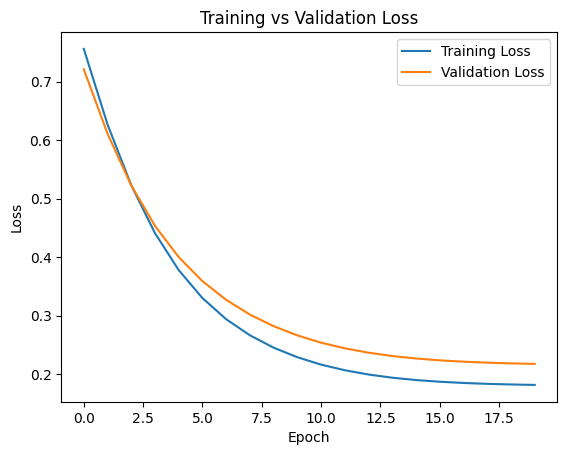

In [23]:
# Plot training and validation loss

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

In [24]:
# Evaluate model performance on test data

results = model.evaluate(
    x=dict(test_features),
    y=test_labels,
    verbose=1
)

print("Test Results:", results)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9213 - loss: 0.1878 - precision: 0.9013 - recall: 0.9013 
Test Results: [0.18779318034648895, 0.9212598204612732, 0.9013158082962036, 0.9013158082962036]


In [25]:
# Generate predictions

predictions = model.predict(dict(test_features))

print(predictions[:5])

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
[[0.01611864]
 [0.5475557 ]
 [0.98843884]
 [0.96097726]
 [0.00119579]]
